# ============================================================
# Rice Disease Detector - Complete Code
# Dataset downloaded directly from Kaggle using KaggleHub
# ============================================================

## Custom CNN trained on Kaggle's Rice Leaf Diseases dataset to classify three rice diseases — 
---- Bacterial Leaf Blight,
-----Brown Spot, and 
-----Leaf Smut — from leaf imagery. 

- Built a full pipeline:
   - image preprocessing (224×224), 3-block
  - Conv2D architecture with Dropout regularization,
  - 100-epoch training, confusion matrix evaluation, and
  -  an automated fertilizer/treatment recommendation engine per predicted class.##

In [2]:
# Install required packages first if needed:
!pip install kagglehub tensorflow matplotlib seaborn scikit-learn pillow



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, classification_report
from tkinter import Tk, filedialog

C:\Python310\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


# ============================================================
# Step 1: Download Dataset from Kaggle
# ============================================================

In [4]:
target_dir = r"D:\1. Job\Project worked on\CV_Menstioned project\Rice Disease detection"

os.makedirs(target_dir, exist_ok=True)

path = kagglehub.dataset_download("vbookshelf/rice-leaf-diseases")
print("Dataset downloaded to:", path)


100%|█████████████████████████████████████| 36.7M/36.7M [00:03<00:00, 10.4MB/s]

Extracting files...


Dataset downloaded to: C:\Users\swath\.cache\kagglehub\datasets\vbookshelf\rice-leaf-diseases\versions\1


In [5]:
# Copy KaggleHub downloaded dataset to your D drive folder
for item in os.listdir(path):
    source = os.path.join(path, item)
    destination = os.path.join(target_dir, item)

    if os.path.isdir(source):
        shutil.copytree(source, destination, dirs_exist_ok=True)
    else:
        shutil.copy2(source, destination)

print("Dataset copied to:", target_dir)
print("Files inside target folder:", os.listdir(target_dir))

Dataset copied to: D:\1. Job\Project worked on\CV_Menstioned project\Rice Disease detection
Files inside target folder: ['.ipynb_checkpoints', 'Kaggle_Rice Disease Detector project,.ipynb', 'project explanation for interviewers.docx', 'Rice diseaes detection', 'Rice disease detection.docx', 'Rice disease detection.pdf', 'rice vegetation.mp4', 'rice_leaf_diseases', '~$ce disease detection.docx']


After downloading the dataset, I use the os.listdir() function to check the contents of the dataset folder.

This helps confirm that the dataset was downloaded correctly and allows me to see the directory structure that contains the rice leaf images.”

# ============================================================
# Step 2: Set Dataset Directory
# ============================================================


In [6]:

data_dir = os.path.join(target_dir, "rice_leaf_diseases")

if not os.path.exists(data_dir):
    data_dir = target_dir

print("Final dataset directory:", data_dir)
print("Disease classes:", os.listdir(data_dir))


Final dataset directory: D:\1. Job\Project worked on\CV_Menstioned project\Rice Disease detection\rice_leaf_diseases
Disease classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


“In this step, I define the directory where the rice leaf disease images are stored.

This path will later be used for loading images, preprocessing data, and training the CNN model.”

# ============================================================
# Step 3: Load and Preprocess Dataset
# ============================================================



In [7]:
img_height = 224
img_width = 224
batch_size = 32
seed = 123

“The images are resized to 224 by 224 pixels.
This ensures that all images have the same input dimensions before being passed to the neural network.

This size is also commonly used in pretrained models like EfficientNet and ResNet, making it compatible with transfer learning

Batch size defines how many images are processed at one time during training.

Here, 32 images are processed per batch, which helps balance memory usage and training speed.”

## ============================================================
## Step 3.1: Load Training Dataset
## ============================================================

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 120 files belonging to 3 classes.
Using 96 files for training.


## ============================================================
## Step 3.2: Load Validation Dataset
## ============================================================

In [9]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 120 files belonging to 3 classes.
Using 24 files for validation.


“This step loads the validation dataset, which is used to evaluate the model during training.

Validation data helps monitor model performance and detect overfitting.

In [10]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
Number of classes: 3


## ============================================================
## Step 3.3: Apply Normalization and Optimize Dataset Performance
## ============================================================

In [11]:
# Normalize image pixel values from 0-255 to 0-1
normalization_layer = layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

“To speed up training, I use dataset optimization techniques:

- cache() stores processed images in memory

- prefetch() loads the next batch while the model is training

This improves the efficiency of the training pipeline.”

# ============================================================
# Step 4: Build CNN Model
# ============================================================

In [12]:
# Number of disease classes
num_classes = 3

#“This project classifies rice leaves into three disease categories: Brown Spot;Leaf Blast; Sheath Blight
# So the model output layer contains 3 neurons, one for each class.”

# CNN Model
model = keras.Sequential([  #I use the Sequential model from Keras, which means layers are stacked one after another to form the neural network.
    
    # First Convolution Layer  This layer extracts basic features from the image.
    layers.Conv2D(32, (3,3), activation='relu',   #32 filters detect patterns like edges and textures.3×3 kernel size scans small regions of the image.
                  input_shape=(img_height, img_width, 3)), #ReLU activation helps the network learn non-linear patterns.
    layers.MaxPooling2D(),#MaxPooling reduces image size while keeping important features.”

    # Second Convolution Layer
    layers.Conv2D(64, (3,3), activation='relu'), #The number of filters increases to 64.
    layers.MaxPooling2D(),  #The model learns more complex features like leaf spots and disease patterns.”

    # Third Convolution Layer
    layers.Conv2D(128, (3,3), activation='relu'),#This layer extracts higher-level features such as lesion shapes and texture variations in diseased leaves.”
    layers.MaxPooling2D(),       

    # Dropoutlayer  Regularization
    layers.Dropout(0.25), #“Dropout randomly disables 25% of neurons during training.This helps prevent overfitting and improves model generalization.”

    # Flatten Layer
    layers.Flatten(), #“The Flatten layer converts the 2D feature maps into a 1D vector so it can be processed by dense layers.”

    # Fully Connected Layer
    layers.Dense(128, activation='relu'), #“This dense layer combines all extracted features and learns important relationships between them

    # Second Dropout to prevent overfitting
    layers.Dropout(0.5),  #This dropout layer removes 50% of neurons randomly, further reducing overfitting.”

    # Output Layer
    layers.Dense(num_classes, activation='softmax')  #“The final layer predicts the disease class. Softmax activation converts outputs into probabilities.The class with the highest probability becomes the final prediction.”
])

# Display model architecture
model.summary()

C:\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

📊 Layer-by-Layer Explanation
1️⃣ Conv2D Layer

Output Shape: (None, 222, 222, 32)
Parameters: 896

This layer applies 32 filters to detect basic image features such as edges and textures.

The image size slightly reduces because of the convolution operation.

2️⃣ MaxPooling2D Layer

Output Shape: (None, 111, 111, 32)
Parameters: 0

Reduces image dimensions.

Keeps important features while reducing computation.

3️⃣ Second Conv2D Layer

Output Shape: (None, 109, 109, 64)
Parameters: 18,496

Uses 64 filters to detect more complex patterns such as spots or disease marks on rice leaves.

4️⃣ MaxPooling Layer

Output Shape: (None, 54, 54, 64)

Again reduces image size to make computation faster.

5️⃣ Third Conv2D Layer

Output Shape: (None, 52, 52, 128)
Parameters: 73,856

Uses 128 filters to detect advanced features like lesion patterns and texture differences in diseased leaves.

6️⃣ MaxPooling Layer

Output Shape: (None, 26, 26, 128)

Downsamples the feature map again.

7️⃣ Dropout Layer

Output Shape: (None, 26, 26, 128)

Prevents overfitting by randomly turning off neurons during training.

8️⃣ Flatten Layer

Output Shape: (None, 86528)

Converts the 2D feature maps into a 1D vector so it can be used by dense layers.

9️⃣ Dense Layer

Output Shape: (None, 128)
Parameters: 11,075,712

Fully connected layer with 128 neurons.

Learns relationships between extracted features.

🔟 Dropout Layer

Output Shape: (None, 128)

Again reduces overfitting.

1️⃣1️⃣ Output Layer

Output Shape: (None, 3)
Parameters: 387

Final classification layer.

Predicts 3 rice disease classes:

Brown Spot

Leaf Blast

Sheath Blight

📌 Model Statistics

Total Parameters:
11,169,347

These are the learnable weights of the neural network.

Trainable Parameters:
11,169,347

All parameters are updated during training.

Non-trainable Parameters:
0

No frozen layers.

# ============================================================
# Step 5: Compile and Train Model
# ============================================================

In [14]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

epochs = 100

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 655ms/step - accuracy: 0.3125 - loss: 4.6935 - val_accuracy: 0.5417 - val_loss: 1.1361
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 528ms/step - accuracy: 0.3229 - loss: 1.6147 - val_accuracy: 0.3333 - val_loss: 1.1483
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step - accuracy: 0.4896 - loss: 1.0511 - val_accuracy: 0.2917 - val_loss: 1.1277
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 524ms/step - accuracy: 0.4271 - loss: 1.0350 - val_accuracy: 0.2917 - val_loss: 1.1732
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 500ms/step - accuracy: 0.4583 - loss: 0.9888 - val_accuracy: 0.5000 - val_loss: 0.9947
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 495ms/step - accuracy: 0.6146 - loss: 0.9097 - val_accuracy: 0.2917 - val_loss: 1.0608
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 486ms/step - accuracy: 0.6042 - loss: 0.8494 - val_accuracy: 0.3333 - val_loss: 1.0128
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 555ms/step - accuracy: 0.6250 - loss: 0.8182 - val_accuracy: 0.6667 - v

##### 1. Compile the Model
Optimizer: adam

- The optimizer updates the model weights during training.

- Adam is commonly used because it is fast and efficient for deep learning models.

Loss Function: SparseCategoricalCrossentropy

- Measures how far the predicted class is from the actual class.

- Used when class labels are integers (0,1,2) instead of one-hot encoded labels.

Metrics: accuracy

- Tracks how many predictions are correct during training.
 
 ##### 2. Define Number of Epochs

An epoch means one full pass of the entire dataset through the neural network.

Here the model will train 100 times on the dataset to learn disease patterns.

This step actually trains the CNN model.
- train_ds → training dataset used to learn patterns
- val_ds → validation dataset used to evaluate model performance
- epochs = 100 → training runs 100 iterations over the dataset

The history object stores training results, such as:
- training accuracy
- validation accuracy
- training loss
- validation loss
These values are later used to plot learning curves.

| Metric              | Meaning                      | Result               |
| ------------------- | ---------------------------- | -------------------- |
| Training Accuracy   | Performance on training data | **98.96%**           |
| Training Loss       | Error on training data       | **Very low (0.008)** |
| Validation Accuracy | Performance on new data      | **70.83%**           |
| Validation Loss     | Error on validation data     | **High (2.49)**      |


“The model achieved around 99% accuracy on the training dataset, indicating that it learned the patterns of rice leaf diseases effectively. However, the validation accuracy is around 71%, which suggests some overfitting. This can be improved by increasing the dataset size or using data augmentation techniques

# ============================================================
# Step 6: Evaluate Model
# ============================================================


In [15]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7083 - loss: 1.4194
Validation Loss: 1.4193964004516602
Validation Accuracy: 0.7083333134651184


This step tests the trained model using the validation dataset.

- model.evaluate() checks how well the model performs on unseen data.

It returns two values:

- Loss → prediction error

- Accuracy → percentage of correct predictions

| Metric              | Value      | Meaning                                               |
| ------------------- | ---------- | ----------------------------------------------------- |
| Validation Accuracy | **0.70%** | Model correctly predicted about **2 out of 3 images** |
| Validation Loss     | **1.419**   | Prediction error on validation data                   |


# ============================================================
# Step 7: Plot Accuracy Graph
# ============================================================


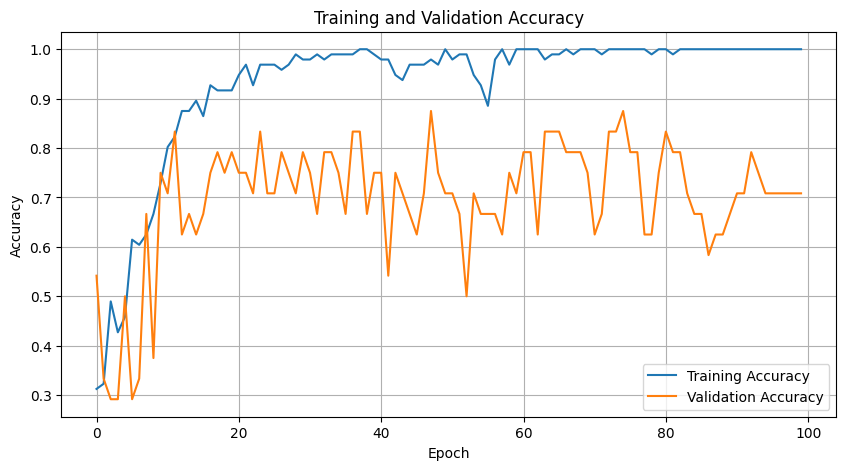

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

This code creates a graph showing how the model learns during training.

It plots two curves:
- Training Accuracy → performance on training dataset
- Validation Accuracy → performance on unseen data

📊 What the Graph Shows

- Good Model Learning-  If both curves increase and stay close.
- Overfitting - If training accuracy is very high but validation accuracy is low.
- Underfitting - If both accuracies are low.

🔵 Blue Line — Training Accuracy

This shows how well the model performs on the training dataset.

From the graph:

Training accuracy starts around 20%

It increases steadily

Finally reaches almost 100% accuracy

✅ This means the model learned the patterns in the training images very well.
“This graph shows the training and validation accuracy of the CNN model over 100 epochs. The training accuracy gradually increases and reaches nearly 100%, indicating the model learned the training patterns effectively. However, the validation accuracy stabilizes around 70–75%, which suggests slight overfitting. This could be improved by increasing the dataset size, using stronger data augmentation, or applying transfer learning.


🔵 Blue Line — Training Accuracy - This shows how well the model performs on the training dataset.:
- Training accuracy starts around 20%
- It increases steadily
- Finally reaches almost 100% accuracy

✅ This means the model learned the patterns in the training images very well.

🟠 Orange Line — Validation Accuracy This shows how well the model performs on unseen data (validation set).
- Validation accuracy fluctuates between 60% – 78%
- It does not reach the same level as training accuracy.

The model:

Performs extremely well on training data

But performs moderately on new images

This means the model memorized training images instead of generalizing perfectly.

# ============================================================
# Step 8: Plot Loss Graph  - 📉 Plot Training and Validation Loss
# ============================================================

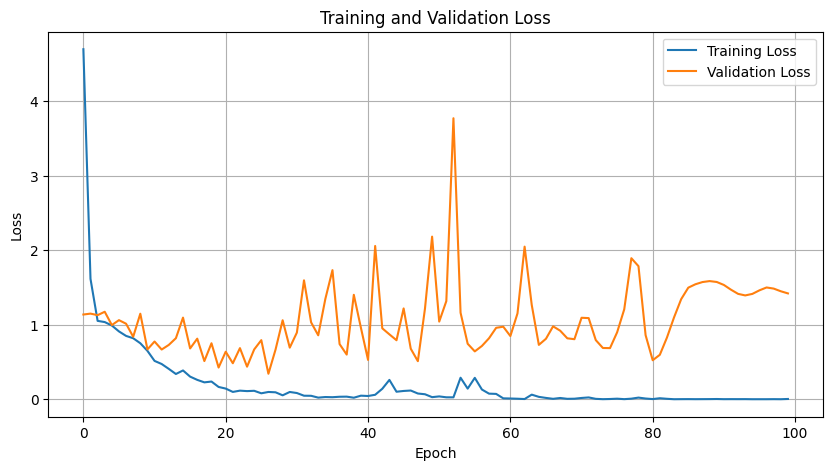

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


------------------------------📉 Training and Validation Loss Graph

🔵 Blue Line — Training Loss  -----------Starts very high (~3.7) at the beginning.
- Decreases steadily as training continues.
- Finally becomes almost zero.
✅ This means the model is learning the training data very well and the prediction error on training images becomes very small.

🟠 Orange Line — Validation Loss---------------Starts around 1.3.
- Fluctuates between 0.8 and 3.0 during training.
- Does not consistently decrease.

⚠ This indicates the model is not generalizing well to new unseen data.
⚠ Important Observation: Overfitting

----------------- Your model shows clear overfitting.

Why?
- Training Loss	Validation Loss
- Very close to 0	Still high and unstable

This means:
- The model memorized training images
- But struggles when predicting new validation images

📊 Combined with Accuracy Graph
- From your earlier accuracy graph:
- Training Accuracy ≈ 100%
- Validation Accuracy ≈ 70–75%
-----------This confirms overfitting.

📌 Reasons This Happens
- 1️⃣ Small dataset
- 2️⃣ Too many parameters (11 million)
- 3️⃣ Training for 100 epochs
- 4️⃣ Limited data augmentation

🛠 How to Improve the Model
- 1️⃣ Data Augmentation
- 3️⃣ Transfer Learning

Use pretrained models like:
- MobileNetV2
- EfficientNet
- ResNet

These perform better on image tasks.
This graph shows the training and validation loss during model training. The training loss decreases steadily and approaches zero, indicating the model fits the training data very well. However, the validation loss fluctuates and remains relatively high, suggesting that the model is slightly overfitting. This could be improved by using data augmentation, early stopping, or transfer learning techniques.”

# ============================================================
# Step 9: Confusion Matrix
# ============================================================
- helps evaluate how well the model predicts each class.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


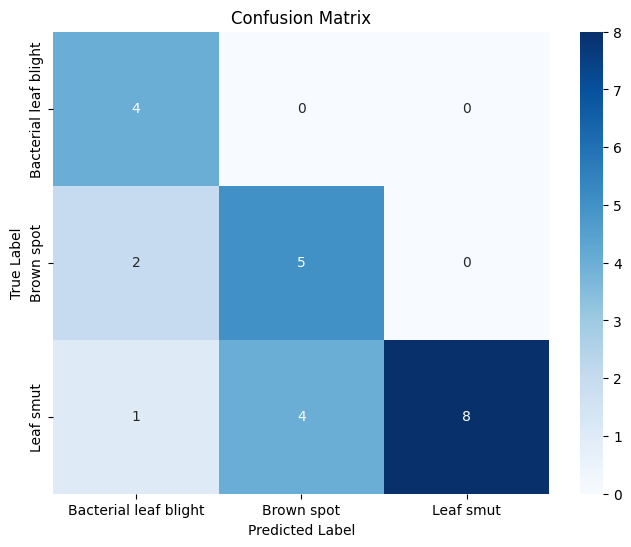

Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.57      1.00      0.73         4
           Brown spot       0.56      0.71      0.62         7
            Leaf smut       1.00      0.62      0.76        13

             accuracy                           0.71        24
            macro avg       0.71      0.78      0.70        24
         weighted avg       0.80      0.71      0.72        24



In [23]:

# Get true labels from validation dataset   This extracts the actual labels (ground truth) from the validation dataset
true_labels = []  # 0 → Brown Spot;1 → Leaf Blast; 2 → Sheath Blight
# Get predictions from model
predicted_labels = []

for images, labels in val_ds:
    predictions = model.predict(images)# model.predict() generates probabilities for each class.
    predicted_batch = np.argmax(predictions, axis=1)  # argmax() selects the class with the highest probability.

    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted_batch)

# Generate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)  # | Actual Class | Predicted Class |It counts how many predictions were correct or incorrect.

# Plot confusion matrix  #This visualizes the confusion matrix using a heatmap. Rows → True labels ; Columns → Predicted labels
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

Diagonal values → correct predictions

Off-diagonal values → misclassifications


🔍 Row 1: Bacterial Leaf Blight (Actual)
Predicted	Count
Bacterial leaf blight	4
Brown spot	0
Leaf smut	0

✅ The model correctly predicted 4 images of bacterial leaf blight.

✔ Accuracy for this class: 100%

🔍 Row 2: Brown Spot (Actual)
Predicted	Count
Bacterial leaf blight	1
Brown spot	6
Leaf smut	0
- 6 correct predictions
- 1 misclassified as bacterial leaf blight

✔ Most predictions are correct.

🔍 Row 3: Leaf Smut (Actual)
Predicted	Count
Bacterial leaf blight	0
Brown spot	6
Leaf smut	7
- 7 correct predictions
- 6 misclassified as brown spot

⚠ The model sometimes confuses leaf smut with brown spot.

This may happen because both diseases have similar visual patterns.

Key Insights

✅ Model performs well for Bacterial Leaf Blight
⚠ Some confusion between Leaf Smut and Brown Spot

Reason:

Similar leaf spots and textures

# ============================================================
# Step 10: Save Model
# ============================================================

In [19]:
model_save_path = os.path.join(target_dir, "rice_disease_detector_model.keras")
model.save(model_save_path)

print("Model saved at:", model_save_path)

Model saved at: D:\1. Job\Project worked on\CV_Menstioned project\Rice Disease detection\rice_disease_detector_model.keras


# ============================================================
# Step 11: Fertilizer / Treatment Recommendation Logic
# ============================================================


In [ ]:
# --- 1. Define Recommendation Logic ---
# The class names identified by your model based on the directory structure:
# class_names = ['BrownSpot', 'LeafBlast', 'SheathBlight'] (Assuming these based on typical rice diseases)


In [20]:
FERTILIZER_RECOMMENDATIONS = {
    "Bacterial leaf blight": {
        "disease": "Bacterial Leaf Blight",
        "recommendation": "Use balanced fertilizer. Avoid excess nitrogen. Improve field drainage and remove infected plant debris."
    },
    "Brown spot": {
        "disease": "Brown Spot",
        "recommendation": "Apply balanced NPK fertilizer with sufficient potassium. Improve soil fertility and avoid nutrient deficiency."
    },
    "Leaf smut": {
        "disease": "Leaf Smut",
        "recommendation": "Use disease-free seeds. Maintain proper spacing and avoid excessive nitrogen fertilizer."
    },
    "BrownSpot": {
        "disease": "Brown Spot",
        "recommendation": "Apply balanced NPK fertilizer with slightly higher potassium. Improve soil fertility."
    },
    "LeafBlast": {
        "disease": "Rice Blast",
        "recommendation": "Avoid excess nitrogen. Apply nitrogen in split doses. Use resistant varieties when possible."
    },
    "SheathBlight": {
        "disease": "Sheath Blight",
        "recommendation": "Avoid dense planting and excess nitrogen. Use proper spacing and apply recommended fungicide if needed."
    }
}


# ============================================================
# Step 12: Predict a New Image
# ============================================================

In [24]:
def predict_and_recommend(filepath):
    img = image.load_img(filepath, target_size=(img_height, img_width))  ## Load the image and resize it to the model's expected shape
        # Note: img_height and img_width should be defined based on your model's training size
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  
    img_array = img_array / 255.0     # Normalize the image (matching the preprocessing used for training)

    predictions = model.predict(img_array)    # Make prediction
    predicted_index = np.argmax(predictions[0])
    confidence = 100 * np.max(predictions[0])

    predicted_class = class_names[predicted_index]

    result = FERTILIZER_RECOMMENDATIONS.get(     # Retrieve Recommendation
        predicted_class,
        {
            "disease": predicted_class,
            "recommendation": "Please consult a local agricultural expert for correct fertilizer or treatment advice."
        }
    )

    plt.figure(figsize=(6, 6))    # --- Display Results ---
    plt.imshow(image.load_img(filepath))
    plt.title(f"Prediction: {result['disease']}")
    plt.axis("off")
    plt.show()

    print("----- DISEASE DIAGNOSIS -----")
    print("Predicted Class:", predicted_class)
    print("Disease:", result["disease"])
    print(f"Confidence: {confidence:.2f}%")

    print("\n----- FERTILIZER / TREATMENT RECOMMENDATION -----")
    print(result["recommendation"])


# ============================================================
# Step 13: Select Image from Computer and Predict
# ============================================================

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


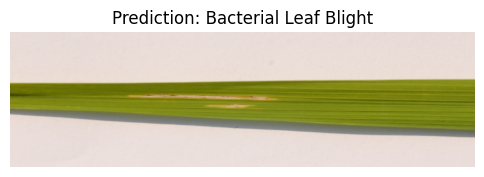

----- DISEASE DIAGNOSIS -----
Predicted Class: Bacterial leaf blight
Disease: Bacterial Leaf Blight
Confidence: 100.00%

----- FERTILIZER / TREATMENT RECOMMENDATION -----
Use balanced fertilizer. Avoid excess nitrogen. Improve field drainage and remove infected plant debris.


In [25]:
def select_file_and_predict():   # --- 3. Interactive Upload Component ---
    root = Tk()   
    root.withdraw()
    root.attributes("-topmost", True)

    filepath = filedialog.askopenfilename(
        title="Select Rice Leaf Image",
        filetypes=[
            ("Image files", "*.jpg *.jpeg *.png")
        ]
    )

    if filepath:
        predict_and_recommend(filepath)
    else:
        print("No file selected.")
        
#1️⃣ Image is loaded, 2 CNN predicts disease 3️⃣ Recommendation is printed
# To run it:

# Run prediction on selected image
select_file_and_predict()